# Preparing multi-qudit states in a definite-weight subspace

Nabi Zare Harofteh and Rafael I. Nepomechie

We prepare arbitrary states of $n$ qudits (each qudit has $d$ levels)
with weight $\vec{k}$
\begin{equation*}
|\psi(\vec{k})\rangle = \sum_{w \in \mathfrak{S}_{M(\vec k)}} a_w | w \rangle \,,
\end{equation*}
where $\mathfrak{S}_{M(\vec k)}$ is the set 
of all unique permutations of the *multiset* $M(\vec k)$ specified by $\vec{k}$
\begin{equation*}
M(\vec k)	=\{ \underbrace{0, \ldots, 0}_{k_{0}}, \underbrace{1, 
\ldots, 1}_{k_{1}}, \ldots, \underbrace{d-1, \ldots, d-1}_{k_{d-1}}\} 
= \{ 0^{k_0}, 1^{k_1}, \ldots, (d-1)^{k_{d-1}} \}\,.
\end{equation*}
 Hence, $\vec k$ is a $d$-dimensional vector such that
\begin{equation*}
\vec k = (k_{0}, k_{1}, \ldots, k_{d-1})\quad \text{with}\quad k_{i} \in \{0, 
1, \ldots, n\}\quad \text{and}\quad \sum_{i=0}^{d-1} k_{i} = n\,.
\end{equation*}
Moreover, $w= w_n \ldots w_1$ with $w_{i} \in \{0, 1, \ldots, d-1\}$ is a permutation in $\mathfrak{S}_{M(\vec k)}$, and 
$|w\rangle = |w_n\rangle \otimes \ldots  \otimes |w_1\rangle$
is the corresponding 
$n$-fold tensor product of computational basis states.
The coefficients $a_w$ are specified arbitrary complex numbers such that 
$|\psi(\vec k)\rangle$ is normalized.

An example with $\vec{k}=(2,1,1)$ (and therefore $d=3, n=4$, and $M(\vec{k})=\{0, 0, 1, 2\}$) is

\begin{align*}
|\psi(2,1,1)\rangle  &= a_{0012}|0012\rangle  + 
a_{0021}|0021\rangle + a_{0120}|0120\rangle + a_{0102}|0102\rangle
+ a_{0201}|0201\rangle + a_{0210}|0210\rangle  \\
& + a_{1200}|1200\rangle  + a_{1002}|1002\rangle
+ a_{1020}|1020\rangle + a_{2010}|2010\rangle
+ a_{2001}|2001\rangle  + a_{2100}|2100\rangle \,.
\end{align*}

In [1]:
import numpy as np
from scipy.special import binom
import sys
import math
import itertools
np.set_printoptions(suppress=True)
np.set_printoptions(threshold=np.inf)

In [2]:
print(sys.version)

3.12.1 (v3.12.1:2305ca5144, Dec  7 2023, 17:23:39) [Clang 13.0.0 (clang-1300.0.29.30)]


## Generating Gray code for multiset permutations (classical)

In [ ]:
# Contructs multiset specified by vector k
def mymultiset(k):
    myms=[]
    for i in range(len(k)):
        myms=myms+([i]*k[i])
    return myms    

In [37]:
#mymultiset([2,1,1])

In [ ]:
# Counts the number of distinct permutations of a multiset specified by vector k
def mycount(k):
    prod=1
    for i in range(len(k)):
        prod=prod*(math.factorial(k[i]))
    return int(math.factorial(sum(k))/prod)

In [38]:
#mycount([2,1,1])

### Ko-Ruskey

C.W. Ko, F. Ruskey, "Generating permutations of a bag by interchanges," Inform. Process. Lett. 41 (5) (1992) 263–269.
Version A of algorithm GenAlt

In [ ]:
# Code generated using Gemini 3 Pro

# Implements the multiset Gray code generation algorithm (Version A) by Ko and Ruskey, 
# which generates all distinct permutations of a multiset specified by the input vector bag_counts. 
# Each element in bag_counts represents the count of a particular item in the multiset. 
# The algorithm uses recursion and backtracking to explore all possible arrangements 
# while maintaining a global direction array to determine the order of traversal at each level of recursion.
def get_multiset_gray_code_version_a(bag_counts):
    # n represents the remaining counts of each element in the bag
    n = list(bag_counts)
    total_size = sum(n)
    t = len(n) - 1

    # pi is the sequence built so far
    pi = [0] * total_size
    
    # d is the global boolean array tracking the direction (increasing/decreasing) 
    # for each depth level k. Initialized to True (plus-node) for all levels.
    d = [True] * total_size

    results = []

    def gen_alt_a(k):
        # Base case: if all elements are exhausted (n_0 = n_1 = ... = n_t = 0)
        if all(count == 0 for count in n):
            results.append(list(pi))
        else:
            # Find available elements (p where n_p > 0)
            current_options = [p for p in range(t + 1) if n[p] > 0]

            # "by d_k": if d[k] is False, traverse children in decreasing order
            if not d[k]:
                current_options.reverse()

            for j in current_options:
                pi[k] = j               # Make a choice for position k
                n[j] -= 1               # Remove element j from the bag
                gen_alt_a(k + 1)        # Recurse to the next level
                n[j] += 1               # Backtrack: return element j to the bag

            # Change(d_k) rule for Version A: Unconditional flip
            d[k] = not d[k]

    # Start recursion at level 0
    gen_alt_a(0)
    return results

In [36]:
#get_multiset_gray_code_version_a([2,1,1])

In [ ]:
# Checks that the generated permutations are correct and that the swap distance is 2 between consecutive permutations
def ko_ruskey_va_plus(k):
    perms=    permutations = get_multiset_gray_code_version_a(k)
    previous = None
    count = 0
    for p in perms:
        count += 1
        diff_msg = ""
        if previous:
            # Calculate the swap distance
            diffs = [j for j in range(len(p)) if p[j] != previous[j]]
            if len(diffs) == 2:
                diff_msg = f" (Swap indices {diffs[0]} & {diffs[1]})"
            else:
                diff_msg = f" (Changed {len(diffs)} positions - ERROR if not 2)"
        
        print(f"{p}{diff_msg}")
        previous = p
    if count==mycount(k):
        print(f"Obtained {count} permutations as expected")
    else:
        print(f"Expected {mycount(k)} permutations, but obtained {count} ")
    return 

In [35]:
#ko_ruskey_va_plus([2,1,1])

## Parameters

$$ w^{[l+1]} = S_{ij}\, w^{[l]}  \,, \qquad i > j $$

For controls: $$ U^{[0]} := \{ r  \in \{1, \ldots, n\} :\ w^{[0]}_r  \ne 0 \}  $$
$$ C^{[l]} := \{ r \in \{1, \ldots, n\}\backslash \{i^{[l]}, j^{[l]}\}:\ w_r^{[l+1]} = w_r^{[l]} \ne 0 \} $$
$$ U^{[l]} :=  U^{[l-1]}\backslash \{i^{[l]}, j^{[l]}\} \,, \qquad l>0 $$
$$ C^{[l]} := C^{[l]}\backslash U^{[l]}  $$
Controls placed at all $r \in C^{[l]}$, with control values $w_r^{[l+1]} = w_r^{[l]}$

In [ ]:
# Computes the swap indices and control sets for each transition in the 
# generated multiset Gray code.
def myparams(vecs):
    dim=len(vecs)
    #untouched
    myu=[0]*(dim-1)
    myu[0]=[index for index, item in enumerate(vecs[0]) if item !=0]
    controls=[0]*(dim-1)
    setij=[0]*(dim-1)
    n=len(vecs[0])
    for l in range(dim-1):
        diffs=[index for index in range(n) if vecs[l+1][index] != vecs[l][index]]
        if len(diffs) == 2:
            j=diffs[0]
            i=diffs[1]
        else:
            raise ValueError(f"Invalid transition at step {l}: vecs must differ by exactly one swap.")
        setij[l]=[i,j]
    
        zero_positions = [index for index in range(n) if vecs[l+1][index] == vecs[l][index]]
        myc=[index for index in zero_positions if vecs[l+1][index]*vecs[l][index] != 0 ]
        if l>0:
            myu[l]= list(set(myu[l-1])-set((i,j)))
        controls[l]= list(set(myc)-set(myu[l])) 
    return setij, controls       

For real amplitudes: 
$$ \theta_l = \begin{cases}
{\rm atan2} \left( \sqrt{\sum_{j=l+1}^{\mathcal{D}-1} a_j^2}, a_l \right) &  l = 0, \ldots, \mathcal{D}-3 \\[0.1 in]
{\rm atan2} \left(a_{\mathcal{D}-1}, a_{\mathcal{D}-2} \right) & l = \mathcal{D}-2
    \end{cases} $$

For complex amplitudes:
$$ \theta_l = \begin{cases}
{\rm atan2} \left( \sqrt{\sum_{j=l+1}^{\mathcal{D}-1} |a_j|^2}, |a_l| \right) &  l = 0, \ldots, \mathcal{D}-3 \\[0.1 in]
{\rm atan2} \left(|a_{\mathcal{D}-1}|, |a_{\mathcal{D}-2}| \right) & l = \mathcal{D}-2
    \end{cases} \,, \qquad
\phi_l = \begin{cases}
\arg \left( \frac{a_{l+1}}{a_l} \frac{1}{\tan(\theta_l) \cos(\theta_{l+1})} \right) &  l = 0, \ldots, \mathcal{D}-3 \\[0.1 in]
\arg \left( \frac{a_{l+1}}{a_l} \frac{1}{\tan(\theta_l)} \right) & l = \mathcal{D}-2
    \end{cases}  $$

In [19]:
# Computes the angles for the state preparation circuit based on the coefficients 
# of the target state. The function takes a list of coefficients and a boolean indicating
# whether the coefficients are complex.
def angleslist(coeffs, is_complex=False):
    dim=len(coeffs)
    thetas=[0]*(dim-1)
    phis=[0]*(dim-1) 
    
    if is_complex:
        for l in range(dim-1):    
            if l>=0 and l<dim-2:
                ss=0
                for j in range(l+1,dim):
                    ss=ss+np.abs(coeffs[j])**2
                thetas[l]=np.arctan2(np.sqrt(ss), np.abs(coeffs[l]))        
            if l==dim-2:
                thetas[l]=np.arctan2(np.abs(coeffs[l+1]), np.abs(coeffs[l]))

        for l in range(dim-1):
            if l>=0 and l<dim-2:
                denom=coeffs[l]*np.tan(thetas[l])*np.cos(thetas[l+1])
                phis[l]=np.angle(coeffs[l+1]/denom)
            if l==dim-2:
                denom=coeffs[l]*np.tan(thetas[l])
                phis[l]=np.angle(coeffs[l+1]/denom)

    else:
        # Real coefficients    
        for l in range(dim-1): 
            if l>=0 and l<dim-2:
                ss=0
                for j in range(l+1,dim):
                    ss=ss+coeffs[j]**2
                thetas[l]=np.arctan2(np.sqrt(ss), coeffs[l])        
            if l==dim-2:
                thetas[l]=np.arctan2(coeffs[l+1], coeffs[l])
    
    return thetas, phis

### $SU(d)$ Dicke state amplitudes

These states are uniform superpositions of the weight-$\vec{k}$ computational basis states

In [20]:
def coefflistDicke(k):
    mc=mycount(k)
    
    return [x/np.sqrt(mc) for x in [1]*mc]

In [34]:
#coefflistDicke([2,1,1])

### $SU_q(d)$ Dicke state amplitudes

These states are $q$-deformations of $SU(d)$ Dicke states, 
see arXiv:2308.08392                   https://arxiv.org/abs/2308.08392  

In [ ]:
# Counts the number of inversions in a given permutation, 
# which is a measure of how far the permutation is from being sorted.
def inv(perm):

    def z(w,j):
        count=0
        for i in range(j):
            if w[i]>w[j]:
                count +=1
        return count

    count=0
    for j in range(len(perm)):
        count += z(perm,j)
    return count   

In [23]:
#q-multinomial
def qmult(k,q):
    eps=1e-10

    def brack(n,q):
        if abs(q-1.0)>eps:
            return (q**n - q**(-n))/(q-q**(-1))
        if abs(q-1.0)<eps:
            return n
        
    def qfac(n,q):
        if n==0:
            return 1
        if abs(q-1.0)<eps:
            return math.factorial(n)
        else:
            return brack(n,q)*qfac(n-1,q)

    prod=1
    for i in range(len(k)):
        prod=prod*(qfac(k[i],q))
        
    return qfac(sum(k),q)/prod

In [24]:
# assume Q is complex
def coefflistqDicke(k,vecs,Q):
    q=abs(Q)
    norm=np.sqrt(qmult(k,q))
    
    def J(kk):
        s=0
        for i in range(len(kk)):
            for j in range(i+1,len(kk)):
                s+= kk[i]*kk[j]
        return s
    
    dim=len(vecs)
    cc=[0]*dim
    for l in range(dim):
        cc[l]= Q**(J(k)/2 - inv(vecs[l]))
        #make sure "first" element is real!
        if l==0:
            pf=np.abs(cc[0])/cc[0]
        cc[l]=cc[l]*pf
    
    return cc/norm

In [33]:
#k=[2,1,1]
#coefflistqDicke(k,get_multiset_gray_code_version_a(k),np.exp(0.5*1j))

### $SU(3)$ Bethe state amplitudes

$$ |\psi\rangle = \sum_{1 \le x_1 < \ldots < x_{m_1} \le n}\sum_{\alpha_1, \ldots, \alpha_{m_1} = 1}^{2} {}^{'}  f(x_1, \ldots, x_{m_1})^{(\alpha_1, \ldots, \alpha_{m_1})}\, e_{x_1}^{\alpha_1,0} \cdots e_{x_{m_1}}^{\alpha_{m_1},0} |0\rangle^{\otimes n} $$

$$ \sum_{j=1}^{m_1} \delta_{2, \alpha_j} = m_2 \,, 
\quad (\alpha_1, \ldots, \alpha_{m_1}) \mapsto (y_1, \ldots y_{m_2}) \,, 
\quad \alpha_{y_l}=2 \,, \quad l = 1, \ldots, m_2$$

\begin{align*} 
f(x_1, \ldots, x_{m_1})^{(\alpha_1, \ldots, \alpha_{m_1})} &= \sum_{P \in S_{m_1}} \sum_{Q \in S_{m_2}} \Big\{ \varepsilon(P) \varepsilon(Q) A(u_{P(1)}, \ldots, u_{P(m_1)}) B(v_{Q(1)}, \ldots, v_{Q(m_2)})   \\
& \times \prod_{j=1}^{m_1}
\left(\frac{u_{P(j)}+\frac{i}{2}}{u_{P(j)}-\frac{i}{2}}\right)^{x_j}
\prod_{a=1}^{m_2} \Phi(v_{Q(a)}, u_{P(1)}, \ldots, u_{P(y_a)}) \Big\}
\end{align*}

\begin{align*}
A(u_1, \ldots, u_{m_1}) &= \prod_{1 \le a < b \le m_1} (u_a - u_b +i) \\
B(v_1, \ldots, v_{m_2}) &= \prod_{1 \le a < b \le m_2} (v_a - v_b +i) \\
\Phi(v, u_1, \ldots, u_y) &= \frac{1}{v-u_y-\frac{i}{2}} 
\prod_{l=1}^{y-1}\frac{v-u_l+\frac{i}{2}}{v-u_l-\frac{i}{2}}
\end{align*}

In [39]:
# uroots=[u_0,...,u_{m1-1}] 
def A(uroots):
    z=1.0
    for b in range(len(uroots)):
        for a in range(b):
            z=z*(uroots[a]-uroots[b]+1.0j)
    return z

# x=[x_0,...,x_{m1-1}] with 1 <= x_0 < x_1 ... < x_{m1-1} <= L
def phase(uroots,x):
    z=1.0
    for a in range(len(uroots)):
        z=z*((uroots[a]+0.5j)/(uroots[a]-0.5j))**x[a]
    return z

# vroots=[v_0,...,v_{m2-1}] 
def B(vroots):
    z=1.0
    for b in range(len(vroots)):
        for a in range(b):
           z=z*(vroots[a]-vroots[b]+1.0j)
    return z

# v is a complex number, y is an integer between 1 and m1, uroots=[u_0,...,u_{m1-1}]
def Phi(v,y,uroots):
    z=1.0
    for a in range(y-1):
        z=z*((v-uroots[a]+0.5j)/(v-uroots[a]-0.5j))   
    z=z/(v-uroots[y-1]-0.5j)    
    return z

# myperms is a collection of permutations t of the numbers 0 to m-1
def myperms(m):
    return list(itertools.permutations(range(m)))

# inversion number of t=(0,1,2,...,m-1)
def inv(t):
    z=0
    for j in range(len(t)):
        for i in range(j):
            if t[i]>t[j]:
                z=z+1
    return z

# sign of permutation t
def eps(t):
    return (-1)**inv(t)

# permutes the bethe roots zBethe into an order determined by permutation t
def zperm(zBethe,t):
    z=[]
    for i in t:
        z.append(zBethe[i])
    return z

# transforms [alpha_0,...,alpha_{m1-1}] into [y_0,...,y_{m2-1}] where alpha_{y_i}=2
def myy(alpha):
    y=[]
    for i in range(len(alpha)):
        if alpha[i]==2:
            y.append(i+1)
    return y

def phiprod(vroots,yvals,uroots):
    z=1.0
    for i in range(len(vroots)):
        z=z*Phi(vroots[i],yvals[i],uroots)
    return z

def f(x,alpha,uBethe,vBethe):
    y=myy(alpha)
    s=0
    for tP in myperms(len(uBethe)):
        uP=zperm(uBethe,tP)
        for tQ in myperms(len(vBethe)):
            vQ=zperm(vBethe,tQ)
            s=s+eps(tP)*eps(tQ)*A(uP)*B(vQ)*phase(uP,x)*phiprod(vQ,y,uP)
    return s


# converts vec to x=[x_0,...,x_{m1-1}] and alpha=[alpha_0,...,alpha_{m1-1}]
def myxa(v):
    x=[]
    alpha=[]
    n=len(v)
    for i in range(n):
        if v[n-1-i] != 0:
            x.append(i)
            alpha.append(v[n-1-i])
    return x, alpha

def coefflistBethe(uBethe,vBethe,vecs):
    dim=len(vecs)
    cc=[0]*dim
    for l in range(dim):
        x, alpha=myxa(vecs[l])
        cc[l]=f(x,alpha,uBethe,vBethe)
        #make sure "first" element is real!
        if l==0:
            pf=np.abs(cc[0])/cc[0]
        cc[l]=cc[l]*pf
    # vector must be normalized
    ss=0
    for j in range(dim):
        ss=ss+np.abs(cc[j])**2
    norm = np.sqrt(ss)    
    return cc/norm  


In [42]:
#k = [2,2,2]
#vecs=get_multiset_gray_code_version_a(k)
#uBethe=[-0.15086911297687333, 0.15086911297687333, -0.6008614236007921, \
#0.6008614236007921]
#vBethe=[-0.46597132203101554, 0.46597132203101554]
#coefflistBethe(uBethe=uBethe,vBethe=vBethe,vecs=vecs)

### Random real amplitudes

In [26]:
import random

random.seed(42)

def coefflistRandomReal(vecs):
    dim=len(vecs)
    random_reals = [random.random() - 0.5 for _ in range(dim)] 

    ss=0
    for j in range(dim):
        ss=ss+random_reals[j]**2
    norm = np.sqrt(ss) 
        
    return [x/norm for x in random_reals]

In [29]:
#k = [2,1,1]
#vecs=get_multiset_gray_code_version_a(k)
#coefflistRandomReal(vecs)

### Random complex amplitudes

In [30]:
def coefflistRandomComplex(vecs):
    dim=len(vecs)
    random_complex = [random.random() - 0.5 + 1j*random.random() for _ in range(dim)] 

    #make sure "first" element is real!
    random_complex[0] = np.real(random_complex[0])

    ss=0
    for j in range(dim):
        ss=ss+np.abs(random_complex[j])**2
    norm = np.sqrt(ss) 
        
    return [x/norm for x in random_complex]

In [32]:
#k = [2,1,1]
#vecs=get_multiset_gray_code_version_a(k)
#coefflistRandomComplex(vecs)

## Hamiltonians for checking eigenstates

### $U(1)$ generators

$$ K^{(a)} = \sum_{i=1}^n e_i^{aa}  \,, \qquad K^{(a)}\, |\psi\rangle = k_a\, |\psi\rangle \,, \qquad a=0, 1, \ldots, d-1 $$

In [43]:
from scipy import sparse

def K(c,d,n):
    def e(a,b,d):
        mat=sparse.lil_matrix((d,d))
        for r in range(d):
            for s in range(d):
                if r==a and s==b:
                    mat[r,s]=1
        return mat.tocsr() 

    I_site = sparse.eye(d, format='csr')     

    def get_full_space_op(op, site_idx):
        """Embeds a single-site operator into the n-site Hilbert space."""
        # op_1 ⊗ op_2 ⊗ ... ⊗ op_n
        op_list = [I_site] * n
        op_list[site_idx] = op
        
        full_op = op_list[0]
        for i in range(1, n):
            full_op = sparse.kron(full_op, op_list[i], format='csr')
        return full_op  

    term = sparse.csr_matrix((d**n, d**n))

    for i in range(n):
        term += get_full_space_op(e(c,c,d), i)

    return term   

### $SU(d)$ Dicke state Hamiltonian

quadratic Casimir operator (up to additive constant and overall factor)

$$ H = -\sum_{i < j} S_{ij} \,, \qquad S_{ij} = \sum_{a, b = 0}^{d-1} e^{a b}_i\, e^{b a}_j $$

In [44]:
from scipy import sparse
from scipy.sparse import lil_matrix, csr_matrix

def HamDicke(d,n):
    def e(a,b,d):
        mat=sparse.lil_matrix((d,d))
        for r in range(d):
            for s in range(d):
                if r==a and s==b:
                    mat[r,s]=1
        return mat.tocsr() 
        
    I_site = sparse.eye(d, format='csr')     

    def get_full_space_op(op, site_idx):
        """Embeds a single-site operator into the n-site Hilbert space."""
        # op_1 ⊗ op_2 ⊗ ... ⊗ op_n
        op_list = [I_site] * n
        op_list[site_idx] = op
        
        full_op = op_list[0]
        for i in range(1, n):
            full_op = sparse.kron(full_op, op_list[i], format='csr')
        return full_op  
        
    casimir = sparse.csr_matrix((d**n, d**n))
    
    for i in range(n):
        for j in range(i+1,n):
            for a in range(d):
                for b in range(d):
                    casimir +=  get_full_space_op(e(a,b,d),i) @ get_full_space_op(e(b,a,d),j)                 
       
    return -casimir
              

### $SU_q(d)$ Dicke state Hamiltonian

Sums of $q$-deformed Jucys-Murphy elements

$$H = -\sum_{i=2}^n J_i \,, \qquad J_i = \check{R}_{i-1} + \check{R}_{i-1}\, J_{i-1}\, \check{R}_{i-1} \,, \qquad J_1 = 0\,, \qquad 
\check{R} = q \sum_a e^{aa} \otimes e^{aa} + \sum_{a\ne b} e^{ab} \otimes e^{ba} + (q-q^{-1})\sum_{a < b} e^{aa} \otimes e^{bb}
$$

$SU_q(d)$ Dicke state eigenvalue:

$$ -\sum_{i=0}^{n-2} (i+1) q^{2n-3-2i} $$

In [45]:
import functools as ft

def HamqDicke(d,n,q):
    def e(a,b,d):
        mat=lil_matrix((d,d))
        for r in range(d):
            for s in range(d):
                if r==a and s==b:
                    mat[r,s]=1
        return mat.tocsr() 

    cr1=sparse.csr_matrix((d**2,d**2))
    cr2=sparse.csr_matrix((d**2,d**2))
    cr3=sparse.csr_matrix((d**2,d**2))
    
    for a in range(d):
        cr1 += sparse.kron(e(a,a,d), e(a,a,d), format='csr')

    for a in range(d):
        for b in range(d):
            if b != a:
                cr2 += sparse.kron(e(a,b,d), e(b,a,d), format='csr')

    for a in range(d):
        for b in range(a+1,d):
            cr3 += sparse.kron(e(a,a,d), e(b,b,d), format='csr')
            
    cr=q*cr1 + cr2 + (q-(1/q))*cr3

    def id(d,m):
        return sparse.eye(d**m, format='csr') 
        
    def R(i,d,n):
        mats=[id(d,i-1), cr, id(d,n-i-1)]
        return ft.reduce(sparse.kron, mats)


    def J(i,d,n):
        if i==1:
            return sparse.csr_matrix((d**n, d**n))
        return R(i-1,d,n) + R(i-1,d,n) @ J(i-1,d,n) @ R(i-1,d,n)
                
    casimir = sparse.csr_matrix((d**n, d**n))

    for i in range(1,n+1):
        casimir += J(i,d,n)

    return casimir


In [47]:
#HamqDicke(2,3,1).toarray()

In [73]:
# Computes the eigenvalue of the q-deformed Dicke state under the action of the 
# q-deformed Casimir operator
def EigqDicke(n,q):
    s=0
    for i in range(n-1):
        s += (i+1)*q**(2*n-3-2*i)
    return s    

In [212]:
#EigqDicke(3,0.3)

### $SU(3)$ Heisenberg Hamiltonian (PBC)

$$H= \sum_{i=1}^L \left(S_{i,i+1} - \mathbb{I}\right) $$

In [48]:
from scipy import sparse
from scipy.sparse import lil_matrix, csr_matrix

def HamHeisenberg(n):
    d=3
    def e(a,b,d):
        mat=sparse.lil_matrix((d,d))
        for r in range(d):
            for s in range(d):
                if r==a and s==b:
                    mat[r,s]=1
        return mat.tocsr() 
        
    I_site = sparse.eye(d, format='csr')     

    def get_full_space_op(op, site_idx):
        """Embeds a single-site operator into the n-site Hilbert space."""
        # op_1 ⊗ op_2 ⊗ ... ⊗ op_n
        op_list = [I_site] * n
        op_list[site_idx] = op
        
        full_op = op_list[0]
        for i in range(1, n):
            full_op = sparse.kron(full_op, op_list[i], format='csr')
        return full_op  
        
    pp = sparse.csr_matrix((d**n, d**n))
    
    for i in range(n):
        for a in range(d):
            for b in range(d):
                pp +=  get_full_space_op(e(a,b,d),i) @ get_full_space_op(e(b,a,d),(i + 1) % n)                 
       
    return pp-n*sparse.eye(d**n, format='csr')


In [49]:
def energy(uBethe):
    ee=0
    for i in range(len(uBethe)):
        ee = ee - 1.0/((1./4.)+uBethe[i]**2)
    return ee    

In [51]:
#HamHeisenberg(2).toarray()

#### Bethe equations

\begin{align}
\left(\frac{{u_j}-\frac{i}{2}}{{u_j}+\frac{i}{2}}\right)^n &=
\prod_{l \ne j}^{m_1} \frac{u_j - u_l -i}{u_j - u_l +i} 
\prod_{l =1}^{m_2} \frac{u_j - v_l +\frac{i}{2}}{u_j - v_l -\frac{i}{2}} \,, \qquad
j = 1, \ldots, m_1 \,, \\
 1 &=
\prod_{l=1}^{m_1} \frac{v_j - u_l + \frac{i}{2}}{v_j - u_l - \frac{i}{2}}
\prod_{l\ne j}^{m_2} \frac{v_j - v_l -i }{v_j - v_l +i} \,, \qquad
j = 1, \ldots, m_2 \,.
\end{align}

In [86]:
# Checks the Bethe equations for the given Bethe roots uBethe and vBethe, 
# by returning the differences between the left-hand side and right-hand side of the equations for each root. The function computes the products and phases involved in the Bethe equations and compares them to ensure that the roots satisfy the equations.	
def BetheCheck(n,uBethe,vBethe):
    m1=len(uBethe)
    m2=len(vBethe)
    
    def rhs1(u,j):
        prod1=1.0 + 0j
        for l in range(m1):
            if l !=j:
                prod1=prod1*(u-uBethe[l]-1j)/(u-uBethe[l]+1j)
        prod2=1.0 + 0j
        for l in range(m2):
            prod2=prod2*(u-vBethe[l]+0.5j)/(u-vBethe[l]-0.5j)
        return prod1*prod2

    diff1=[0.0 + 0j]*m1
    for j in range(m1):
        lhs=((uBethe[j] - 0.5j)/(uBethe[j] + 0.5j))**n
        diff1[j]= lhs - rhs1(uBethe[j],j)

    def rhs2(v,j):
        prod1=1.0 + 0j
        for l in range(m1):
            prod1=prod1*((v-uBethe[l]+0.5j)/(v-uBethe[l]-0.5j))   
        prod2=1.0 + 0j
        for l in range(m2):
            if l !=j:
                prod2=prod2*(v-vBethe[l]-1j)/(v-vBethe[l]+1j)
        return prod1*prod2

    diff2=[0.0 + 0j]*m2
    for j in range(m2):
        diff2[j]= 1.0+ 0j - rhs2(vBethe[j],j)

    return np.round(diff1, 6), np.round(diff2, 6)

## Quantum gates

In [25]:
# pip install cirq

In [52]:
import cirq

simulator=cirq.Simulator()

In [53]:
print(cirq.__version__)

1.5.0


Elementary 1-qudit gates:

$$ {\rm X}\, |\mu\rangle = |\mu+1 \rangle\,, \qquad 
{\rm X}^\dagger\, |\mu\rangle = |\mu-1 \rangle  $$

$$R_{m_j,m_i}(\theta,\phi) = \cos(\theta) |m_j\rangle\langle m_j | 
-  \sin(\theta) |m_j\rangle\langle m_i |  
+ e^{i \phi} \sin(\theta) |m_i\rangle\langle m_j | 
+ e^{i \phi} \cos(\theta) |m_i\rangle\langle m_i|  $$

In [54]:
class oplus(cirq.Gate):
    def __init__(self, d, power):
        super(oplus, self)
        self.d=d
        self.power = power
        
    def _qid_shape_(self):
        return (self.d,)
        
    def _unitary_(self):
        v=np.ones((self.d-1,), dtype=int)
        mat=np.diag(v,-1)
        mat[0,self.d-1]=1
        matp=np.linalg.matrix_power(mat, self.power)
        return matp
        
    def _circuit_diagram_info_(self, args):
        return f"oplus {self.power}"

class ominus(cirq.Gate):
    def __init__(self, d, power):
        super(ominus, self)
        self.d=d
        self.power = power
        
    def _qid_shape_(self):
        return (self.d,)
        
    def _unitary_(self):
        v=np.ones((self.d-1,), dtype=int)
        mat=np.diag(v,1)
        mat[self.d-1,0]=1
        matp=np.linalg.matrix_power(mat, self.power)
        return matp
        
    def _circuit_diagram_info_(self, args):
        return f"ominus {self.power}"

class R(cirq.Gate):
    def __init__(self, d, theta, phi, i, j):
        if i == j or not (0 <= i < d) or not (0 <= j < d):
            raise ValueError("Indices i and j must be different and in range [0, d-1]")
        super().__init__()
        self.d = d
        self.theta = theta
        self.phi = phi
        self.i = i
        self.j = j
        
    def _qid_shape_(self):
        return (self.d,)

    def _unitary_(self):
        U = np.eye(self.d, dtype=np.complex128)
        c, s, phase = np.cos(self.theta), np.sin(self.theta), np.exp(self.phi*1j)
        U[self.i, self.i] = c
        U[self.j, self.j] = phase*c
        U[self.i, self.j] = -s
        U[self.j, self.i] = phase*s
        return U

    def _circuit_diagram_info_(self, args):
        return f"R{self.i}{self.j}({self.theta:.2f})"


Gray gate:

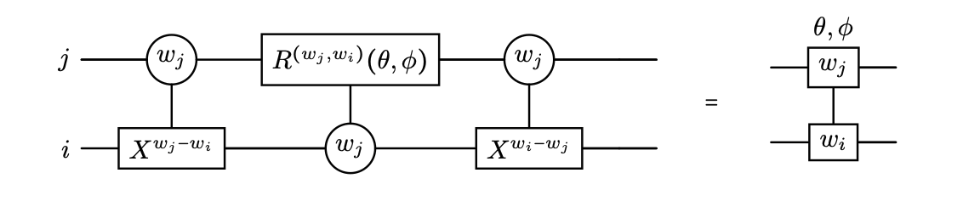

In [55]:
from IPython.display import display, Image
display(Image(filename="GrayGate.png", height=300, width=500))

In [56]:
def GrayGate(qr,d,vecs,setij,controls,thetas,phis,l):
    """Gives generator"""
    i=setij[l][0]
    j=setij[l][1]

    zero_positions = controls[l]
  
    numzeros = len(zero_positions)

    mytheta=thetas[l]

    myphi=phis[l]

    extra_control_qudits = [qr[m] for m in zero_positions]

    extra_control_values = [vecs[l][m] for m in zero_positions]

    coplus_vals = extra_control_values + [vecs[l][j]]
    
    total_controls = len(coplus_vals)

    Coplus = cirq.ControlledGate(oplus(d, vecs[l][j]-vecs[l][i]), 
        num_controls=total_controls,
        control_values=tuple(coplus_vals),
        control_qid_shape=tuple([d] * total_controls))

    cominus_vals = extra_control_values + [vecs[l][j]]

    Cominus = cirq.ControlledGate(oplus(d, vecs[l][i]-vecs[l][j]), 
        num_controls=total_controls, 
        control_values=tuple(cominus_vals),
        control_qid_shape=tuple([d] * total_controls))

    cr_vals = extra_control_values + [vecs[l][j]]

    CR = cirq.ControlledGate(R(d, mytheta, myphi, vecs[l][j], vecs[l][i]), 
        num_controls=total_controls, 
        control_values=tuple(cr_vals),
        control_qid_shape=tuple([d] * total_controls))


    yield Coplus(*extra_control_qudits, qr[j], qr[i])
    yield CR(*extra_control_qudits, qr[i], qr[j])
    yield Cominus(*extra_control_qudits, qr[j], qr[i])
    

Initial state:

$$ |w^{[0]}\rangle = \prod_{r=1}^n
{\rm X}^{w^{[0]}_{r}}_r\, |0\rangle^{\otimes n} $$

In [57]:
def initstate(qr,d,vecs):
    """Gives generator"""
    # initial state
    init=vecs[0]
    for r in range(len(init)):
        yield oplus(d,init[r])(qr[r])   

## Quantum circuits

Prepare states and check that they are eigenstates of the corresponding Hamiltonians

$$ |\psi\rangle = \overset{\curvearrowleft}{\prod_{l=0}^{\mathcal{D}-2}} G^{[l]} \, |w^{[0]}\rangle  $$

### $SU(d)$ Dicke states

In [59]:
def myDickestate(qr,k):
    """Gives generator"""
    d=len(k)
    vecs=get_multiset_gray_code_version_a(k)
    setij, controls=myparams(vecs)
    coeffs=coefflistDicke(k)
    thetas, phis=angleslist(coeffs,False)
    # initial state
    yield initstate(qr,d,vecs)
    # apply Gray gates
    for l in range(len(vecs)-1):
        yield GrayGate(qr,d,vecs,setij,controls,thetas,phis,l)

#### $d=2$

In [60]:
k=[2,3]
d=len(k)
n=sum(k)
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myDickestate(qr,k))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.32|00111⟩ + 0.32|01011⟩ + 0.32|01101⟩ + 0.32|01110⟩ + 0.32|10011⟩ + 0.32|10101⟩ + 0.32|10110⟩ + 0.32|11001⟩ + 0.32|11010⟩ + 0.32|11100⟩


In [61]:
psi=result.final_state_vector
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamDicke(d,n) @ psi, -(n*(n-1)/2.) * psi))

True
True
True


In [62]:
k=[1,4]
d=len(k)
n=sum(k)
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myDickestate(qr,k))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.45|01111⟩ + 0.45|10111⟩ + 0.45|11011⟩ + 0.45|11101⟩ + 0.45|11110⟩


In [63]:
psi=result.final_state_vector
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamDicke(d,n) @ psi, -(n*(n-1)/2.) * psi))

True
True
True


#### $d=3$

In [64]:
k=[1,1,1]
d=len(k)
n=sum(k)
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myDickestate(qr,k))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.41|012⟩ + 0.41|021⟩ + 0.41|102⟩ + 0.41|120⟩ + 0.41|201⟩ + 0.41|210⟩


In [65]:
psi=result.final_state_vector
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamDicke(d,n) @ psi, -(n*(n-1)/2.) * psi))

True
True
True
True


In [66]:
k=[1,2,3]
d=len(k)
n=sum(k)
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myDickestate(qr,k))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.13|011222⟩ + 0.13|012122⟩ + 0.13|012212⟩ + 0.13|012221⟩ + 0.13|021122⟩ + 0.13|021212⟩ + 0.13|021221⟩ + 0.13|022112⟩ + 0.13|022121⟩ + 0.13|022211⟩ + 0.13|101222⟩ + 0.13|102122⟩ + 0.13|102212⟩ + 0.13|102221⟩ + 0.13|110222⟩ + 0.13|112022⟩ + 0.13|112202⟩ + 0.13|112220⟩ + 0.13|120122⟩ + 0.13|120212⟩ + 0.13|120221⟩ + 0.13|121022⟩ + 0.13|121202⟩ + 0.13|121220⟩ + 0.13|122012⟩ + 0.13|122021⟩ + 0.13|122102⟩ + 0.13|122120⟩ + 0.13|122201⟩ + 0.13|122210⟩ + 0.13|201122⟩ + 0.13|201212⟩ + 0.13|201221⟩ + 0.13|202112⟩ + 0.13|202121⟩ + 0.13|202211⟩ + 0.13|210122⟩ + 0.13|210212⟩ + 0.13|210221⟩ + 0.13|211022⟩ + 0.13|211202⟩ + 0.13|211220⟩ + 0.13|212012⟩ + 0.13|212021⟩ + 0.13|212102⟩ + 0.13|212120⟩ + 0.13|212201⟩ + 0.13|212210⟩ + 0.13|220112⟩ + 0.13|220121⟩ + 0.13|220211⟩ + 0.13|221012⟩ + 0.13|221021⟩ + 0.13|221102⟩ + 0.13|221120⟩ + 0.13|221201⟩ + 0.13|221210⟩ + 0.13|222011⟩ + 0.13|222101⟩ + 0.13|222110⟩


In [67]:
psi=result.final_state_vector
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamDicke(d,n) @ psi, -(n*(n-1)/2.) * psi))

True
True
True
True


#### $d=4$

In [68]:
k=[1,1,1,1]
d=len(k)
n=sum(k)
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myDickestate(qr,k))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.2|0123⟩ + 0.2|0132⟩ + 0.2|0213⟩ + 0.2|0231⟩ + 0.2|0312⟩ + 0.2|0321⟩ + 0.2|1023⟩ + 0.2|1032⟩ + 0.2|1203⟩ + 0.2|1230⟩ + 0.2|1302⟩ + 0.2|1320⟩ + 0.2|2013⟩ + 0.2|2031⟩ + 0.2|2103⟩ + 0.2|2130⟩ + 0.2|2301⟩ + 0.2|2310⟩ + 0.2|3012⟩ + 0.2|3021⟩ + 0.2|3102⟩ + 0.2|3120⟩ + 0.2|3201⟩ + 0.2|3210⟩


In [69]:
psi=result.final_state_vector
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamDicke(d,n) @ psi, -(n*(n-1)/2.) * psi))

True
True
True
True
True


### $SU_q(d)$ Dicke states

In [70]:
# assume Q is complex
def myqDickestate(qr,k,Q):
    """Gives generator"""
    d=len(k)
    vecs=get_multiset_gray_code_version_a(k)
    setij, controls=myparams(vecs)
    coeffs=coefflistqDicke(k,vecs,Q)
    thetas, phis=angleslist(coeffs,True)
    # initial state
    yield initstate(qr,d,vecs)
    # apply Gray gates
    for l in range(len(vecs)-1):
        yield GrayGate(qr,d,vecs,setij,controls,thetas,phis,l)

#### $d=2$

In [71]:
k=[2,3]
Q=0.7*np.exp(0.3*1j)
d=len(k)
n=sum(k)
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myqDickestate(qr,k,Q))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.08|00111⟩ + (0.1-0.03j)|01011⟩ + (0.13-0.09j)|01101⟩ + (0.14-0.17j)|01110⟩ + (0.13-0.09j)|10011⟩ + (0.14-0.17j)|10101⟩ + (0.12-0.3j)|10110⟩ + (0.12-0.3j)|11001⟩ + (0.03-0.45j)|11010⟩ + (-0.15-0.63j)|11100⟩


In [74]:
psi=result.final_state_vector
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamqDicke(d,n,Q) @ psi, EigqDicke(n,Q) * psi))

True
True
True


In [213]:
#formatted_list = [f"{num:,.8f}" for num in psi]
#output = ", ".join(formatted_list)
#print(output)

#### $d=3$

In [75]:
k=[1,1,1]
Q=0.7*np.exp(0.3*1j)
d=len(k)
n=sum(k)
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myqDickestate(qr,k,Q))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.21|012⟩ + (0.29-0.09j)|021⟩ + (0.29-0.09j)|102⟩ + (0.36-0.25j)|120⟩ + (0.36-0.25j)|201⟩ + (0.39-0.49j)|210⟩


In [76]:
psi=result.final_state_vector
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamqDicke(d,n,Q) @ psi, EigqDicke(n,Q) * psi))

True
True
True
True


In [62]:
#psi=result.final_state_vector
#formatted_list = [f"{num:,.8f}" for num in psi]
#output = ", ".join(formatted_list)
#print(output)

In [77]:
k=[1,2,3]
Q=0.7*np.exp(0.3*1j)
d=len(k)
n=sum(k)
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myqDickestate(qr,k,Q))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.01|011222⟩ + 0.01|012122⟩ + (0.02-0.01j)|012212⟩ + (0.02-0.02j)|012221⟩ + (0.02-0.01j)|021122⟩ + (0.02-0.02j)|021212⟩ + (0.01-0.04j)|021221⟩ + (0.01-0.04j)|022112⟩ - 0.05j|022121⟩ + (-0.02-0.08j)|022211⟩ + 0.01|101222⟩ + (0.02-0.01j)|102122⟩ + (0.02-0.02j)|102212⟩ + (0.01-0.04j)|102221⟩ + (0.02-0.01j)|110222⟩ + (0.02-0.02j)|112022⟩ + (0.01-0.04j)|112202⟩ - 0.05j|112220⟩ + (0.02-0.02j)|120122⟩ + (0.01-0.04j)|120212⟩ - 0.05j|120221⟩ + (0.01-0.04j)|121022⟩ - 0.05j|121202⟩ + (-0.02-0.08j)|121220⟩ - 0.05j|122012⟩ + (-0.02-0.08j)|122021⟩ + (-0.02-0.08j)|122102⟩ + (-0.06-0.1j)|122120⟩ + (-0.06-0.1j)|122201⟩ + (-0.12-0.11j)|122210⟩ + (0.02-0.02j)|201122⟩ + (0.01-0.04j)|201212⟩ - 0.05j|201221⟩ - 0.05j|202112⟩ + (-0.02-0.08j)|202121⟩ + (-0.06-0.1j)|202211⟩ + (0.01-0.04j)|210122⟩ - 0.05j|210212⟩ + (-0.02-0.08j)|210221⟩ - 0.05j|211022⟩ + (-0.02-0.08j)|211202⟩ + (-0.06-0.1j)|211220⟩ + (-0.02-0.08j)|212012⟩ + (-0.06-0.1j)|212021⟩ + (-0.06-0.1j)|212102⟩ + (-0.12-0.11j)|212120⟩ + (-0.12-0.11j)|21220

In [78]:
psi=result.final_state_vector
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamqDicke(d,n,Q) @ psi, EigqDicke(n,Q) * psi))

True
True
True
True


In [221]:
#psi=result.final_state_vector
#formatted_list = [f"{num:,.8f}" for num in psi]
#output = ", ".join(formatted_list)
#print(output)

#### $d=4$

In [79]:
k=[1,1,1,1]
Q=0.7*np.exp(0.3*1j)
d=len(k)
n=sum(k)
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myqDickestate(qr,k,Q))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.05|0123⟩ + (0.07-0.02j)|0132⟩ + (0.07-0.02j)|0213⟩ + (0.09-0.06j)|0231⟩ + (0.09-0.06j)|0312⟩ + (0.1-0.12j)|0321⟩ + (0.07-0.02j)|1023⟩ + (0.09-0.06j)|1032⟩ + (0.09-0.06j)|1203⟩ + (0.1-0.12j)|1230⟩ + (0.1-0.12j)|1302⟩ + (0.08-0.21j)|1320⟩ + (0.09-0.06j)|2013⟩ + (0.1-0.12j)|2031⟩ + (0.1-0.12j)|2103⟩ + (0.08-0.21j)|2130⟩ + (0.08-0.21j)|2301⟩ + (0.02-0.32j)|2310⟩ + (0.1-0.12j)|3012⟩ + (0.08-0.21j)|3021⟩ + (0.08-0.21j)|3102⟩ + (0.02-0.32j)|3120⟩ + (0.02-0.32j)|3201⟩ + (-0.1-0.45j)|3210⟩


In [80]:
psi=result.final_state_vector
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamqDicke(d,n,Q) @ psi, EigqDicke(n,Q) * psi))

True
True
True
True
True


In [224]:
#psi=result.final_state_vector
#formatted_list = [f"{num:,.8f}" for num in psi]
#output = ", ".join(formatted_list)
#print(output)

### $SU(3)$ Bethe states

In [81]:
def myBethestate(qr,n,uBethe,vBethe):
    """Gives generator"""
    d=3
    m1=len(uBethe)
    m2=len(vBethe)
    k=[(n-m1),(m1-m2),m2]
    vecs=get_multiset_gray_code_version_a(k)
    setij, controls=myparams(vecs)
    coeffs=coefflistBethe(uBethe,vBethe,vecs)
    thetas, phis=angleslist(coeffs,True)
    # initial state
    yield initstate(qr,d,vecs)
    # apply Gray gates
    for l in range(len(vecs)-1):
        yield GrayGate(qr,d,vecs,setij,controls,thetas,phis,l)

#### $m_1=2, m_2=0$

In [89]:
uBethe=[0.2886751345948129,-0.2886751345948129]
vBethe=[]
n=4
d=3
BetheCheck(n,uBethe,vBethe)

(array([0.+0.j, 0.+0.j]), array([], dtype=float64))

In [90]:
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myBethestate(qr,n,uBethe,vBethe))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.29|0011⟩ - 0.58|0101⟩ + 0.29|0110⟩ + 0.29|1001⟩ - 0.58|1010⟩ + 0.29|1100⟩


In [91]:
psi=result.final_state_vector
m1=len(uBethe)
m2=len(vBethe)
k=[(n-m1),(m1-m2),m2]
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamHeisenberg(n) @ psi, energy(uBethe) * psi))

True
True
True
True


In [92]:
uBethe=[0.5,-0.5]
vBethe=[]
n=5
d=3
BetheCheck(n,uBethe,vBethe)

(array([0.+0.j, 0.+0.j]), array([], dtype=float64))

In [93]:
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myBethestate(qr,n,uBethe,vBethe))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.32|00011⟩ - 0.32|00101⟩ + 0.32|00110⟩ - 0.32|01001⟩ - 0.32|01010⟩ + 0.32|01100⟩ + 0.32|10001⟩ - 0.32|10010⟩ - 0.32|10100⟩ + 0.32|11000⟩


In [94]:
psi=result.final_state_vector
m1=len(uBethe)
m2=len(vBethe)
k=[(n-m1),(m1-m2),m2]
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamHeisenberg(n) @ psi, energy(uBethe) * psi))

True
True
True
True


#### $m_1=2, m_2=1$

In [95]:
uBethe=[0.2886751345948129,-0.2886751345948129]
vBethe=[0]
n=3
d=3
BetheCheck(n,uBethe,vBethe)

(array([-0.+0.j, -0.-0.j]), array([0.+0.j]))

In [96]:
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myBethestate(qr,n,uBethe,vBethe))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.41|012⟩ - 0.41|021⟩ - 0.41|102⟩ + 0.41|120⟩ + 0.41|201⟩ - 0.41|210⟩


In [97]:
psi=result.final_state_vector
m1=len(uBethe)
m2=len(vBethe)
k=[(n-m1),(m1-m2),m2]
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamHeisenberg(n) @ psi, energy(uBethe) * psi))

True
True
True
True


In [98]:
uBethe=[0.5,0]
vBethe=[0.25]
n=4
d=3
BetheCheck(n,uBethe,vBethe)

(array([0.+0.j, 0.+0.j]), array([0.+0.j]))

In [99]:
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myBethestate(qr,n,uBethe,vBethe))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.25|0012⟩ - 0.25|0021⟩ + (-0.25+0.25j)|0102⟩ - 0.25j|0120⟩ + (0.25-0.25j)|0201⟩ + 0.25j|0210⟩ - 0.25j|1002⟩ + (0.25+0.25j)|1020⟩ - 0.25|1200⟩ + 0.25j|2001⟩ + (-0.25-0.25j)|2010⟩ + 0.25|2100⟩


In [100]:
psi=result.final_state_vector
m1=len(uBethe)
m2=len(vBethe)
k=[(n-m1),(m1-m2),m2]
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamHeisenberg(n) @ psi, energy(uBethe) * psi))

True
True
True
True


#### $m_1=3, m_2=1$

In [101]:
uBethe=[0.5390996433799916, -0.19607666515343664 - 
  0.5002178630304553*1j, -0.19607666515343664 + 
  0.5002178630304553*1j]
vBethe=[0.29389262614623657]
n=5
d=3
BetheCheck(n,uBethe,vBethe)

(array([ 0.-0.j,  0.+0.j, -0.-0.j]), array([0.+0.j]))

In [102]:
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myBethestate(qr,n,uBethe,vBethe))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.26|00112⟩ + (-0.05+0.15j)|00121⟩ + (-0.21-0.15j)|00211⟩ - 0.1|01012⟩ + (-0.03+0.09j)|01021⟩ - 0.16|01102⟩ + (0.08-0.24j)|01120⟩ + (0.08+0.06j)|01201⟩ + (0.13+0.09j)|01210⟩ + (0.13-0.09j)|02011⟩ + (0.08-0.06j)|02101⟩ + (-0.21+0.15j)|02110⟩ - 0.16|10012⟩ + (0.08-0.24j)|10021⟩ - 0.1|10102⟩ + (-0.03+0.09j)|10120⟩ + (0.13+0.09j)|10201⟩ + (0.08+0.06j)|10210⟩ + 0.26|11002⟩ + (-0.05+0.15j)|11020⟩ + (-0.21-0.15j)|11200⟩ + (-0.21+0.15j)|12001⟩ + (0.08-0.06j)|12010⟩ + (0.13-0.09j)|12100⟩ + (0.08+0.24j)|20011⟩ + (-0.03-0.09j)|20101⟩ + (-0.05-0.15j)|20110⟩ + (-0.05-0.15j)|21001⟩ + (-0.03-0.09j)|21010⟩ + (0.08+0.24j)|21100⟩


In [103]:
psi=result.final_state_vector
m1=len(uBethe)
m2=len(vBethe)
k=[(n-m1),(m1-m2),m2]
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamHeisenberg(n) @ psi, energy(uBethe) * psi))

True
True
True
True


In [104]:
uBethe=[-0.3840352543145401, 0.06570592636335025, 0.5560934570249783]
vBethe=[0.47552825814757677]
n=5
d=3
BetheCheck(n,uBethe,vBethe)

(array([-0.-0.j, -0.+0.j,  0.+0.j]), array([-0.-0.j]))

In [105]:
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myBethestate(qr,n,uBethe,vBethe))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.1|00112⟩ + (-0.13+0.09j)|00121⟩ + (0.03-0.09j)|00211⟩ - 0.26|01012⟩ + (0.21-0.15j)|01021⟩ + 0.16|01102⟩ + (-0.08+0.06j)|01120⟩ + (-0.08+0.24j)|01201⟩ + (0.05-0.15j)|01210⟩ + (0.05+0.15j)|02011⟩ + (-0.08-0.24j)|02101⟩ + (0.03+0.09j)|02110⟩ + 0.16|10012⟩ + (-0.08+0.06j)|10021⟩ - 0.26|10102⟩ + (0.21-0.15j)|10120⟩ + (0.05-0.15j)|10201⟩ + (-0.08+0.24j)|10210⟩ + 0.1|11002⟩ + (-0.13+0.09j)|11020⟩ + (0.03-0.09j)|11200⟩ + (0.03+0.09j)|12001⟩ + (-0.08-0.24j)|12010⟩ + (0.05+0.15j)|12100⟩ + (-0.08-0.06j)|20011⟩ + (0.21+0.15j)|20101⟩ + (-0.13-0.09j)|20110⟩ + (-0.13-0.09j)|21001⟩ + (0.21+0.15j)|21010⟩ + (-0.08-0.06j)|21100⟩


In [106]:
psi=result.final_state_vector
m1=len(uBethe)
m2=len(vBethe)
k=[(n-m1),(m1-m2),m2]
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamHeisenberg(n) @ psi, energy(uBethe) * psi))

True
True
True
True


#### $m_1=4, m_2=2$

In [108]:
uBethe=[-0.15086911297687333, 0.15086911297687333, -0.6008614236007921, \
0.6008614236007921]
vBethe=[-0.46597132203101554, 0.46597132203101554]
n=6
d=3
BetheCheck(n,uBethe,vBethe)


(array([ 0.+0.j,  0.+0.j, -0.-0.j, -0.+0.j]), array([0.+0.j, 0.-0.j]))

In [109]:
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myBethestate(qr,n,uBethe,vBethe))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.03|001122⟩ - 0.08|001212⟩ + 0.05|001221⟩ + 0.05|002112⟩ - 0.08|002121⟩ + 0.03|002211⟩ - 0.08|010122⟩ + 0.16|010212⟩ - 0.08|010221⟩ + 0.05|011022⟩ - 0.08|011202⟩ + 0.03|011220⟩ - 0.21|012012⟩ + 0.16|012021⟩ + 0.16|012102⟩ - 0.08|012120⟩ - 0.08|012201⟩ + 0.05|012210⟩ - 0.08|020112⟩ + 0.16|020121⟩ - 0.08|020211⟩ + 0.16|021012⟩ - 0.21|021021⟩ - 0.08|021102⟩ + 0.05|021120⟩ + 0.16|021201⟩ - 0.08|021210⟩ + 0.05|022011⟩ - 0.08|022101⟩ + 0.03|022110⟩ + 0.05|100122⟩ - 0.08|100212⟩ + 0.03|100221⟩ - 0.08|101022⟩ + 0.16|101202⟩ - 0.08|101220⟩ + 0.16|102012⟩ - 0.08|102021⟩ - 0.21|102102⟩ + 0.16|102120⟩ + 0.05|102201⟩ - 0.08|102210⟩ + 0.03|110022⟩ - 0.08|110202⟩ + 0.05|110220⟩ + 0.05|112002⟩ - 0.08|112020⟩ + 0.03|112200⟩ - 0.08|120012⟩ + 0.05|120021⟩ + 0.16|120102⟩ - 0.21|120120⟩ - 0.08|120201⟩ + 0.16|120210⟩ - 0.08|121002⟩ + 0.16|121020⟩ - 0.08|121200⟩ + 0.03|122001⟩ - 0.08|122010⟩ + 0.05|122100⟩ + 0.03|200112⟩ - 0.08|200121⟩ + 0.05|200211⟩ - 0.08|201012⟩ + 0.16|201021⟩ + 0.05|201102⟩ - 0.08|20112

In [110]:
psi=result.final_state_vector
m1=len(uBethe)
m2=len(vBethe)
k=[(n-m1),(m1-m2),m2]
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamHeisenberg(n) @ psi, energy(uBethe) * psi))

True
True
True
True


In [111]:
uBethe=[-0.38045490745354477 + 0.5032996851609899*1j, 0.38045490745354477 - 
 0.5032996851609899 * 1j, -0.38045490745354477 - 
 0.5032996851609899 * 1j, 0.38045490745354477 + 0.5032996851609899 * 1j]
vBethe=[0 - 0.619512663003751 * 1j, 0 + 0.619512663003751 * 1j]
n=6
d=3
BetheCheck(n,uBethe,vBethe)

(array([-0.-0.j,  0.-0.j,  0.+0.j, -0.+0.j]), array([-0.+0.j, -0.+0.j]))

In [112]:
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myBethestate(qr,n,uBethe,vBethe))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

0.18|001122⟩ - 0.02|001212⟩ - 0.16|001221⟩ - 0.16|002112⟩ - 0.02|002121⟩ + 0.18|002211⟩ - 0.02|010122⟩ + 0.05|010212⟩ - 0.02|010221⟩ - 0.16|011022⟩ - 0.02|011202⟩ + 0.18|011220⟩ + 0.11|012012⟩ + 0.05|012021⟩ + 0.05|012102⟩ - 0.02|012120⟩ - 0.02|012201⟩ - 0.16|012210⟩ - 0.02|020112⟩ + 0.05|020121⟩ - 0.02|020211⟩ + 0.05|021012⟩ + 0.11|021021⟩ - 0.02|021102⟩ - 0.16|021120⟩ + 0.05|021201⟩ - 0.02|021210⟩ - 0.16|022011⟩ - 0.02|022101⟩ + 0.18|022110⟩ - 0.16|100122⟩ - 0.02|100212⟩ + 0.18|100221⟩ - 0.02|101022⟩ + 0.05|101202⟩ - 0.02|101220⟩ + 0.05|102012⟩ - 0.02|102021⟩ + 0.11|102102⟩ + 0.05|102120⟩ - 0.16|102201⟩ - 0.02|102210⟩ + 0.18|110022⟩ - 0.02|110202⟩ - 0.16|110220⟩ - 0.16|112002⟩ - 0.02|112020⟩ + 0.18|112200⟩ - 0.02|120012⟩ - 0.16|120021⟩ + 0.05|120102⟩ + 0.11|120120⟩ - 0.02|120201⟩ + 0.05|120210⟩ - 0.02|121002⟩ + 0.05|121020⟩ - 0.02|121200⟩ + 0.18|122001⟩ - 0.02|122010⟩ - 0.16|122100⟩ + 0.18|200112⟩ - 0.02|200121⟩ - 0.16|200211⟩ - 0.02|201012⟩ + 0.05|201021⟩ - 0.16|201102⟩ - 0.02|20112

In [113]:
psi=result.final_state_vector
m1=len(uBethe)
m2=len(vBethe)
k=[(n-m1),(m1-m2),m2]
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

print(np.allclose(HamHeisenberg(n) @ psi, energy(uBethe) * psi))

True
True
True
True


### State with random real amplitudes

In [117]:
def myRandomRealstate(qr,k):
    """Gives generator"""
    d=len(k)
    vecs=get_multiset_gray_code_version_a(k)
    setij, controls=myparams(vecs)
    coeffs=coefflistRandomReal(vecs)
    thetas, phis=angleslist(coeffs,False)
    print([[vecs[l], coeffs[l]] for l in range(len(vecs))])
    # initial state
    yield initstate(qr,d,vecs)
    # apply Gray gates
    for l in range(len(vecs)-1):
        yield GrayGate(qr,d,vecs,setij,controls,thetas,phis,l)

In [118]:
k=[1,2,2]
d=len(k)
n=sum(k)
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myRandomRealstate(qr,k))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

[[[0, 1, 1, 2, 2], -0.1692426162172718], [[0, 1, 2, 2, 1], -0.2922606213697551], [[0, 1, 2, 1, 2], -0.11527214140091425], [[0, 2, 2, 1, 1], -0.14507422801950443], [[0, 2, 1, 2, 1], -0.1805265606991601], [[0, 2, 1, 1, 2], 0.27665128403212], [[1, 2, 0, 1, 2], 0.23508761212904447], [[1, 2, 0, 2, 1], -0.11575632815736803], [[1, 2, 1, 2, 0], 0.09709045647514723], [[1, 2, 1, 0, 2], -0.0651906419052172], [[1, 2, 2, 0, 1], 0.2589356685624292], [[1, 2, 2, 1, 0], -0.025702050437817883], [[1, 1, 2, 2, 0], -0.14686109095030053], [[1, 1, 2, 0, 2], -0.15826210865596754], [[1, 1, 0, 2, 2], 0.03833190504836795], [[1, 0, 1, 2, 2], -0.1481968819493341], [[1, 0, 2, 1, 2], 0.05283429567943157], [[1, 0, 2, 2, 1], 0.24848904416381468], [[2, 0, 2, 1, 1], -0.0628366877607883], [[2, 0, 1, 1, 2], -0.1753185127060839], [[2, 0, 1, 2, 1], 0.3107730836244743], [[2, 1, 0, 2, 1], 0.00595033545745914], [[2, 1, 0, 1, 2], -0.255527103480867], [[2, 1, 1, 0, 2], -0.28288121077671186], [[2, 1, 1, 2, 0], -0.2438218576299982

In [119]:
psi=result.final_state_vector
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))


True
True
True


In [120]:
k=[1,1,1,1]
d=len(k)
n=sum(k)
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myRandomRealstate(qr,k))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

[[[0, 1, 2, 3], 0.3376709495131763], [[0, 1, 3, 2], 0.019815853429501797], [[0, 2, 3, 1], 0.32062613989128175], [[0, 2, 1, 3], 0.24555447410802397], [[0, 3, 1, 2], -0.3324965900400085], [[0, 3, 2, 1], 0.15022804759102185], [[1, 3, 2, 0], 0.12367601012457667], [[1, 3, 0, 2], 0.025162807067319305], [[1, 2, 0, 3], -0.1587038225870756], [[1, 2, 3, 0], 0.09594165111064878], [[1, 0, 3, 2], -0.2643859982706886], [[1, 0, 2, 3], -0.044400182344806464], [[2, 0, 1, 3], -0.03149664708302877], [[2, 0, 3, 1], 0.3088769427273736], [[2, 1, 3, 0], 0.2558136462359352], [[2, 1, 0, 3], -0.16104253329986978], [[2, 3, 0, 1], 0.00039892122794731835], [[2, 3, 1, 0], -0.21871648541562758], [[3, 2, 1, 0], 0.2808434384337685], [[3, 2, 0, 1], 0.25218295818756464], [[3, 1, 0, 2], -0.13718283742968151], [[3, 1, 2, 0], 0.09457203364844655], [[3, 0, 2, 1], 0.07416748447158607], [[3, 0, 1, 2], -0.23628510782140114]]
0.34|0123⟩ + 0.02|0132⟩ + 0.25|0213⟩ + 0.32|0231⟩ - 0.33|0312⟩ + 0.15|0321⟩ - 0.04|1023⟩ - 0.26|1032⟩ -

In [121]:
psi=result.final_state_vector
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

True
True
True
True


### State with random complex amplitudes

In [122]:
def myRandomComplexstate(qr,k):
    """Gives generator"""
    d=len(k)
    vecs=get_multiset_gray_code_version_a(k)
    setij, controls=myparams(vecs)
    coeffs=coefflistRandomComplex(vecs)
    thetas, phis=angleslist(coeffs,True)
    print([[vecs[l], coeffs[l]] for l in range(len(vecs))])
    # initial state
    yield initstate(qr,d,vecs)
    # apply Gray gates
    for l in range(len(vecs)-1):
        yield GrayGate(qr,d,vecs,setij,controls,thetas,phis,l)

In [123]:
k=[1,1,1]
d=len(k)
n=sum(k)
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myRandomComplexstate(qr,k))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

[[[0, 1, 2], 0.1582437007287258], [[0, 2, 1], (0.16795836623441962+0.3197016189779941j)], [[1, 2, 0], (-0.30105942834359456+0.19540397598638382j)], [[1, 0, 2], (-0.28966342927346295+0.5600683984718399j)], [[2, 0, 1], (0.22829670808407207+0.5013349206849845j)], [[2, 1, 0], (-0.11603209134850195+0.0349177737020485j)]]
0.16|012⟩ + (0.17+0.32j)|021⟩ + (-0.29+0.56j)|102⟩ + (-0.3+0.2j)|120⟩ + (0.23+0.5j)|201⟩ + (-0.12+0.03j)|210⟩


In [125]:
psi=result.final_state_vector
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

True
True
True


In [126]:
k=[1,2,2]
d=len(k)
n=sum(k)
qr=cirq.LineQid.range(n, dimension=d)
test=cirq.Circuit(myRandomComplexstate(qr,k))
#print(test)
result=simulator.simulate(test)
print(cirq.dirac_notation(result.final_state_vector, qid_shape=(d,)*n))

[[[0, 1, 1, 2, 2], 0.1170557255753058], [[0, 1, 2, 2, 1], (-0.1283079474964276+0.15049344362151634j)], [[0, 1, 2, 1, 2], (-0.13339910236571315+0.23553062809993905j)], [[0, 2, 2, 1, 1], (0.08231918467401231+0.03975813330228045j)], [[0, 2, 1, 2, 1], (-0.007654142043592183+0.1702540324266274j)], [[0, 2, 1, 1, 2], (-0.07275335554027836+0.2701605537402813j)], [[1, 2, 0, 1, 2], (-0.023801364298532756+0.06558614560522937j)], [[1, 2, 0, 2, 1], (0.012168559195419398+0.22603291316463622j)], [[1, 2, 1, 2, 0], (-0.09254256819400314+0.09652711658302147j)], [[1, 2, 1, 0, 2], (0.1533296173804344+0.2012434280310295j)], [[1, 2, 2, 0, 1], (-0.019168136485674784+0.16027427806130326j)], [[1, 2, 2, 1, 0], (-0.11736111711462177+0.06958053413577661j)], [[1, 1, 2, 2, 0], (-0.05013897013159444+0.1821776591025619j)], [[1, 1, 2, 0, 2], (-0.08357358084163548+0.06819325693197323j)], [[1, 1, 0, 2, 2], (-0.13284772582436244+0.19542946721862772j)], [[1, 0, 1, 2, 2], (-0.08393680011286411+0.28037541056100845j)], [[1, 

In [127]:
psi=result.final_state_vector
for a in range(d):
    print(np.allclose(K(a,d,n) @ psi, k[a] * psi))

True
True
True
